In [55]:
using Pkg
Pkg.activate(".")
Pkg.add(["Polyhedra", "CDDLib", "Plots", "HiGHS", "NEOSServer", "JuMP", "MAT"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/felipe/trabuco/Polyhedron`
project at `~/felipe/trabuco/Polyhedron`
   Resolving package versions...
   Resolving package versions...
   Installed aws_c_sdkutils_jll ────────── v0.2.4+1
   Installed aws_c_sdkutils_jll ────────── v0.2.4+1
   Installed MPIPreferences ────────────── v0.1.12
   Installed aws_c_auth_jll ────────────── v0.9.6+0
   Installed MicrosoftMPI_jll ──────────── v10.1.4+3
   Installed aws_c_cal_jll ─────────────── v0.9.13+0
   Installed HDF5_jll ──────────────────── v2.0.1+0
   Installed StringEncodings ───────────── v0.3.7
   Installed MPIPreferences ────────────── v0.1.12
   Installed aws_c_auth_jll ────────────── v0.9.6+0
   Installed MicrosoftMPI_jll ──────────── v10.1.4+3
   Installed aws_c_cal_jll ─────────────── v0.9.13+0
   Installed HDF5_jll ──────────────────── v2.0.1+0
   Installed StringEncodings ───────────── v0.3.7
   Installed MAT ───────────────────────── v0.12.0
   Installed MAT ───────────────────────── v0.12.0
   Installe

In [56]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.8

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

In [57]:
F = [-0.00027006642627346196	0.0012823330118505785	6.824918352815799e-5	-0.004012552960055027;
0.0019525481906939837	0.0026136341328765345	-0.00011647561340133348	3.5995003671514546e-5;
0.0025325911326408803	0.003381459063452969	-0.00015121417757781456	3.110267291936144e-5;
-0.00156395800188867	-0.002094200878244854	9.282577885460676e-5	-5.24805408730955e-5;
0.004837995138577335	0.0064128684268341075	-0.00028699984279758326	0.0001098983336928772;
0.014745024118466728	0.044121034072765734	-0.0014433271893221364	7.939055636410599e-5;
0.0018255360878248056	0.002445758697420251	-0.000108900755678278	3.4953663735978724e-5;
-0.00019438134947595683	0.0006891807906518217	3.9160298253465495e-5	-4.85851656927105e-5;
-0.34307070857543587	-0.35465591373729766	0.0167280470905377	7.861708412932681e-7;
0.0007506724051765118	0.0007759551659017869	0.0033033531445050626	6.592904587270658e-8;
0.000616494417221039	0.0008336725062177303	-3.7171794973366386e-5	3.1601822593019304e-6;
0.0017048580688207107	0.0022852483761339943	-0.0001017383434344746	3.357158803995746e-5;
-0.0004908770655942276	0.0034905214284034394	-0.0001354719621801307	-0.012665483149430118;
1.9291316030317837e-5	2.6002826672489576e-5	-1.1526078521929377e-6	6.324548805048901e-7;
-0.03566475995122655	-0.21443279247147043	0.006936389543578625	-5.5192420357487447e-8;
4.506902292074185e-5	6.437569342375458e-5	-3.105984293177733e-6	-1.5033166506153483e-5;
0.00046847369323718506	-0.01924319499516943	0.0006545235670990252	0.05911379710272295;
0.006748914749991202	0.009565161152527077	-0.0004427867834707643	0.00012215822636952044;
-0.000730178170327679	-0.000979580296787138	4.318659470684938e-5	-3.606087241875755e-5;
-0.0037241409873612066	-0.004948713555700932	0.00022035814753009036	-0.00010900328342912255;
-0.014459322793902496	-0.04178573317775897	0.001317510267640634	-0.00018479220766598264;
-0.000694842711316665	-0.0009321527711048144	4.10803650403326e-5	-3.5157922875611755e-5;
0.0006258686101659117	0.0008452813369497798	-3.7618595802473294e-5	7.791987170537089e-6;
0.00028841482939448296	0.00039237593290968145	-1.7592835802295944e-5	-6.3548367073199015e-6]

G = [-0.9576915989859672 -1.0298732907204187	0.04924582993278632	0.12102123914734642]

F = vcat(F, -F)

48×4 Matrix{Float64}:
 -0.000270066   0.00128233    6.82492e-5   -0.00401255
  0.00195255    0.00261363   -0.000116476   3.5995e-5
  0.00253259    0.00338146   -0.000151214   3.11027e-5
 -0.00156396   -0.0020942     9.28258e-5   -5.24805e-5
  0.004838      0.00641287   -0.000287      0.000109898
  0.014745      0.044121     -0.00144333    7.93906e-5
  0.00182554    0.00244576   -0.000108901   3.49537e-5
 -0.000194381   0.000689181   3.91603e-5   -4.85852e-5
 -0.343071     -0.354656      0.016728      7.86171e-7
  0.000750672   0.000775955   0.00330335    6.5929e-8
  ⋮                                        
 -4.5069e-5    -6.43757e-5    3.10598e-6    1.50332e-5
 -0.000468474   0.0192432    -0.000654524  -0.0591138
 -0.00674891   -0.00956516    0.000442787  -0.000122158
  0.000730178   0.00097958   -4.31866e-5    3.60609e-5
  0.00372414    0.00494871   -0.000220358   0.000109003
  0.0144593     0.0417857    -0.00131751    0.000184792
  0.000694843   0.000932153  -4.10804e-5    3.51579e-

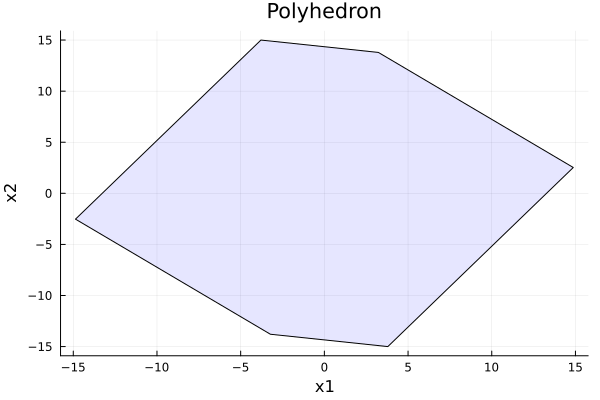

In [58]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

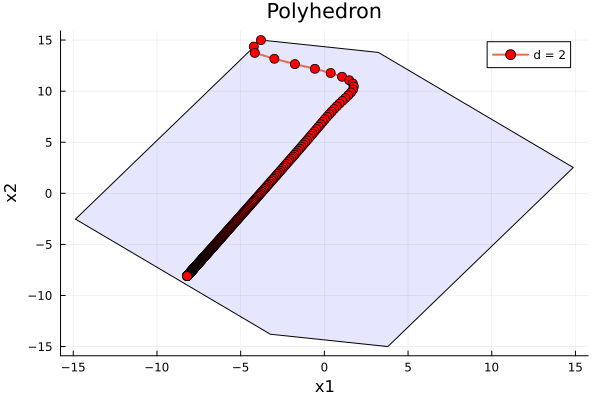

In [60]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 300
r = ones(passos)*-8.3 # escolher a referência a se seguir 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 400, nx)
traj = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj]
x2 = [p[2] for p in traj]
v = [p[3] for p in traj]
w = [p[4] for p in traj]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")


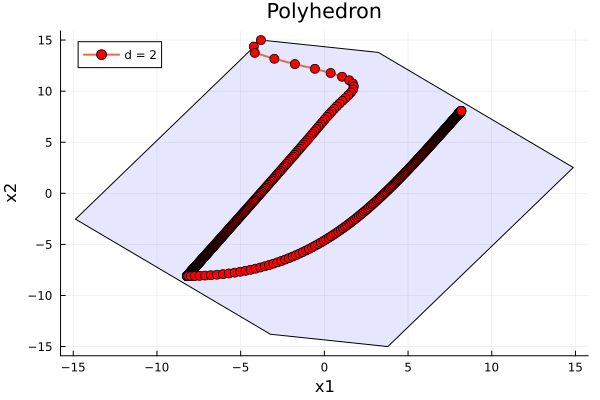

In [61]:
r = ones(passos)* 8.3
a = Vector{Tuple{Float64, Float64, Float64, Float64}}(undef, 2)
fill!(a, (0.0, 0.0, 0.0, 0.0))
traj_temp = vcat(a, traj)
traj2 = Poly.trajectory_segref_delay(traj_temp, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj2]
x2 = [p[2] for p in traj2]
v = [p[3] for p in traj2]
w = [p[4] for p in traj2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

Computed u for traj; length = 301



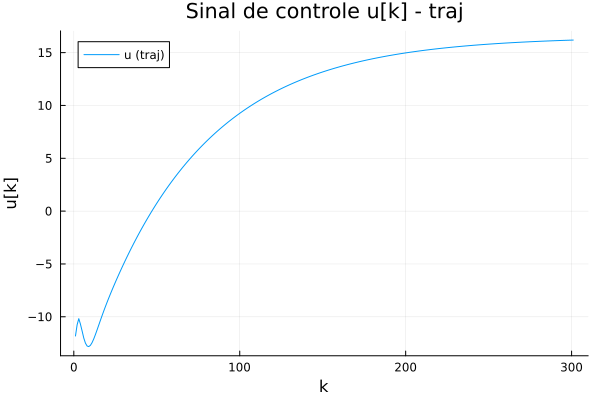

In [62]:
# Cálculo simples do sinal de controle usando `Gx = G[:, 1:2]`
using Plots

# Use as duas primeiras colunas de G
Gx = G[:, 1:2]

# Calcular u para `traj` (assume que `traj` existe)
u = [(Gx * [p[1]; p[2]])[1] for p in traj]
println("Computed u for traj; length = ", length(u))
plot(u, label = "u (traj)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj")

Computed u2 for traj2; length = 601



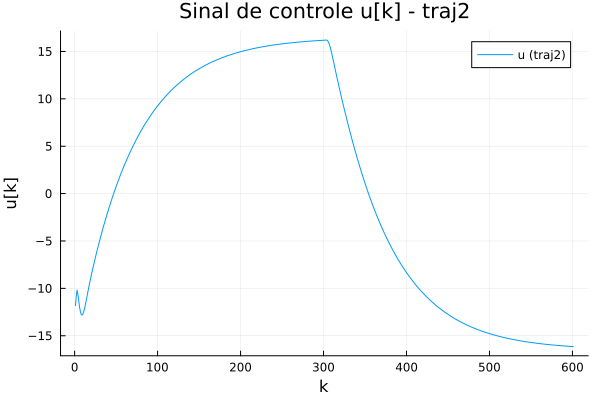

In [64]:
# Calcular u2 para `traj2` (assume que `traj2` existe)
u2 = [(Gx * [p[1]; p[2]])[1] for p in traj2]
println("Computed u2 for traj2; length = ", length(u2))
plot(u2, label = "u (traj2)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj2")


In [65]:
using MAT

# Converte traj e traj2 (vetor de tuplas) para matrizes Nx4
traj_mat = traj isa Vector && !isempty(traj) ? vcat([collect(p)' for p in traj]...) : zeros(0,4)
traj2_mat = traj2 isa Vector && !isempty(traj2) ? vcat([collect(p)' for p in traj2]...) : zeros(0,4)

# Abre o arquivo .mat para escrita
file = matopen("saved_simulation.mat", "w")

# Salva escalares e arrays
write(file, "d", d)
write(file, "t", t)
write(file, "delta", delta)
write(file, "passos", passos)

write(file, "A", A)
write(file, "B", B)
write(file, "C", C)

write(file, "A_exp", A_exp)
write(file, "B_exp", B_exp)
write(file, "E_exp", E_exp)

write(file, "S", S)
write(file, "R", R)
write(file, "F", F)
write(file, "G", G)

# T: se for array/Matrix, salva; se for otro tipo, tenta converter ou omite
try
    write(file, "T", T)
catch
    println("T não pôde ser salvo como array.")
end

write(file, "init_cond_F", init_cond_F)
write(file, "init_cond_w", init_cond_w)

# Trajetórias e controles
write(file, "traj", traj_mat)
write(file, "traj2", traj2_mat)
write(file, "u", u)
write(file, "u2", u2)

close(file)

println("Variáveis exportadas para saved_simulation.mat")

Variáveis exportadas para saved_simulation.mat
